# Seasonal Agriculture Performance Analysis

**A Data Analytics Project on Seasonal Variation in Agricultural Performance (India)**

## 1. Introduction to the Dataset
This dataset captures agricultural activity across different **seasons** (Kharif, Rabi, Zaid),
**states/districts**, and **farming conditions** in India. It includes environmental
conditions (rainfall, temperature, humidity, soil), resource usage (fertilizer, water,
irrigation method), crop production (yield, production), and economic performance
(cost, revenue, profit).

## 2. Problem Statement
Agricultural performance is influenced by seasonal variation in environmental conditions,
farming practices, resource availability and market conditions. Raw agricultural data alone
does not reveal *how* performance changes across seasons. This notebook investigates seasonal
differences in agricultural performance by identifying patterns, trends, relationships and
variations in the data.

## 3. Objective
- Explore and clean the dataset
- Examine how performance varies across seasons (Kharif / Rabi / Zaid)
- Identify seasonal patterns in environmental conditions, resource usage and economics
- Test for statistically significant differences between seasons
- Derive evidence-based insights and recommendations for seasonal agricultural planning

## 4. Key Analytical Questions
1. How does yield and profit vary across seasons?
2. What environmental conditions (rainfall, temperature, humidity) differ by season?
3. How does resource usage (fertilizer, water, irrigation) change across seasons?
4. Are seasonal patterns consistent across states and crops?
5. What relationships exist between environmental/resource variables and yield/profit?
6. Are there unusual or unexpected seasonal patterns (e.g. outliers, high disease risk)?


## 5. Setup: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display / plotting settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']


## 6. Load the Dataset
Place `seasonal_agriculture_performance_dataset.csv` in the project root (same folder as this
notebook) before running.

In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape: 4000 rows, 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 7. Data Cleaning & Preparation

### 7.1 Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)


,Missing Count,Missing %
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


We have missing values in `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`
(each under 1.5% of rows). Since the proportion is small, we impute numeric columns with the
**median of their respective Season group** — this preserves seasonal patterns better than a
global median.

In [6]:
num_cols_with_na = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in num_cols_with_na:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:\n", df[num_cols_with_na].isnull().sum())


Remaining missing values:
 Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


### 7.2 Duplicate Records

In [7]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
df.drop_duplicates(inplace=True)


Duplicate rows: 0


### 7.3 Outlier Check
`Yield_Tonnes_Ha` has a very high max value relative to its median, which is worth
inspecting — a few farms may have data-entry errors (e.g. yield recorded in the wrong unit).
We cap extreme outliers using the IQR method rather than deleting rows, so we don't lose
other valid information from those farms.

In [8]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_cols = ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3', 'Profit_INR']
for col in outlier_cols:
    low, high = iqr_bounds(df[col])
    n_outliers = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: {n_outliers} potential outliers (bounds: {low:.2f} to {high:.2f})")


Yield_Tonnes_Ha: 302 potential outliers (bounds: -1.62 to 5.50)
Water_Efficiency_t_per_1000m3: 322 potential outliers (bounds: -3.57 to 10.38)
Profit_INR: 404 potential outliers (bounds: -696111.00 to 763567.00)


In [9]:
# Cap (winsorize) extreme outliers instead of dropping rows
for col in outlier_cols:
    low, high = iqr_bounds(df[col])
    df[col] = df[col].clip(lower=low, upper=high)

print("Outliers capped. Updated summary:")
df[outlier_cols].describe().T


Outliers capped. Updated summary:


,count,mean,std,min,25%,50%,75%,max
Yield_Tonnes_Ha,4000.0,2.097255,1.416959,0.300,1.050,1.7300,2.83000,5.500000
Water_Efficiency_t_per_1000m3,4000.0,3.796316,2.872332,0.135,1.661,2.9375,5.15025,10.384125
Profit_INR,4000.0,49017.631000,348821.555312,-696111.000,-148731.750,3673.0000,216187.75000,763567.000000


### 7.4 Feature Engineering
A few derived metrics make seasonal comparison easier.

In [10]:
df['Cost_per_Hectare'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Revenue_per_Hectare'] = df['Revenue_INR'] / df['Farm_Area_Hectares']
df['Profit_per_Hectare'] = df['Profit_INR'] / df['Farm_Area_Hectares']
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

df['Season'] = pd.Categorical(df['Season'], categories=SEASON_ORDER, ordered=True)

df[['Cost_per_Hectare', 'Revenue_per_Hectare', 'Profit_per_Hectare', 'Profit_Margin_pct']].describe().T


,count,mean,std,min,25%,50%,75%,max
Cost_per_Hectare,4000.0,66660.084938,8845.644258,35807.382550,60597.205943,66614.048166,72739.977527,97185.351090
Revenue_per_Hectare,4000.0,80215.109448,58262.570038,4439.466896,42325.161826,67082.984401,96800.414327,422793.509615
Profit_per_Hectare,4000.0,7880.653006,45624.387036,-83127.365729,-25353.732021,778.694926,31262.419140,307778.378378
Profit_Margin_pct,4000.0,-46.942407,152.574873,-1461.851219,-60.192762,1.146236,29.865551,83.746016


## 8. Dataset Overview

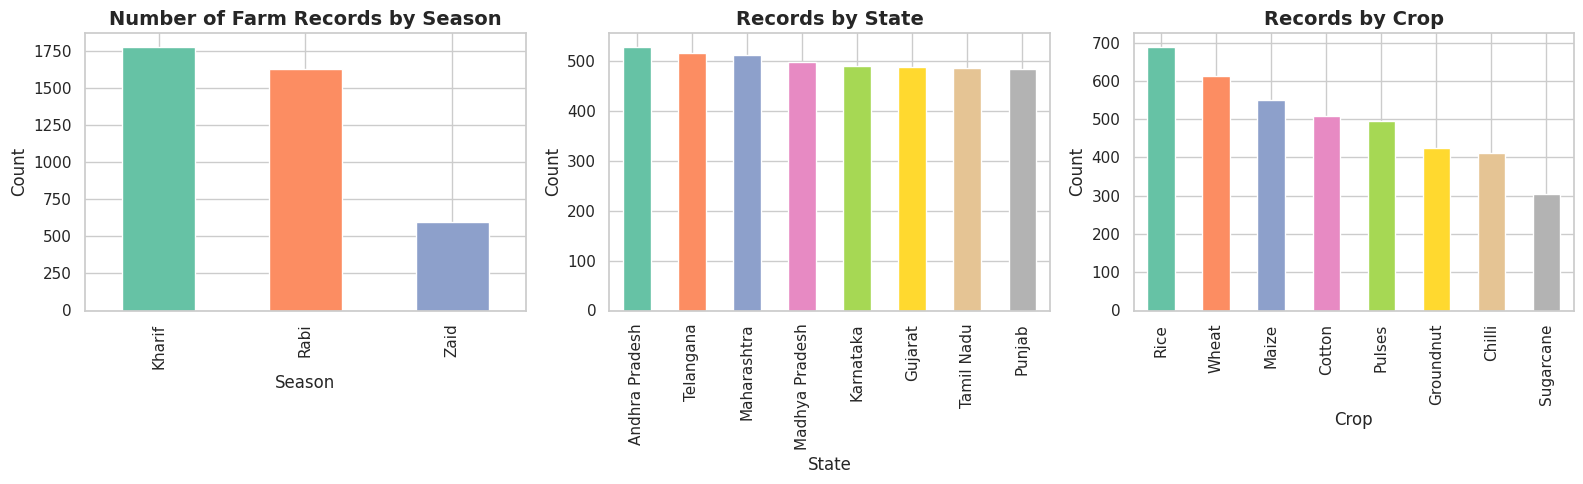

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

season_counts = df['Season'].value_counts().reindex(SEASON_ORDER)
season_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette("Set2"))
axes[0].set_title('Number of Farm Records by Season')
axes[0].set_ylabel('Count')

df['State'].value_counts().plot(kind='bar', ax=axes[1], color=sns.color_palette("Set2"))
axes[1].set_title('Records by State')
axes[1].set_ylabel('Count')

df['Crop'].value_counts().plot(kind='bar', ax=axes[2], color=sns.color_palette("Set2"))
axes[2].set_title('Records by Crop')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [12]:
pd.crosstab(df['Season'], df['Crop'])


Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,185,215,193,234,221,314,125,292
Rabi,163,201,177,233,213,274,129,237
Zaid,64,92,54,84,62,102,51,85


## 9. Seasonal Differences in Environmental Conditions

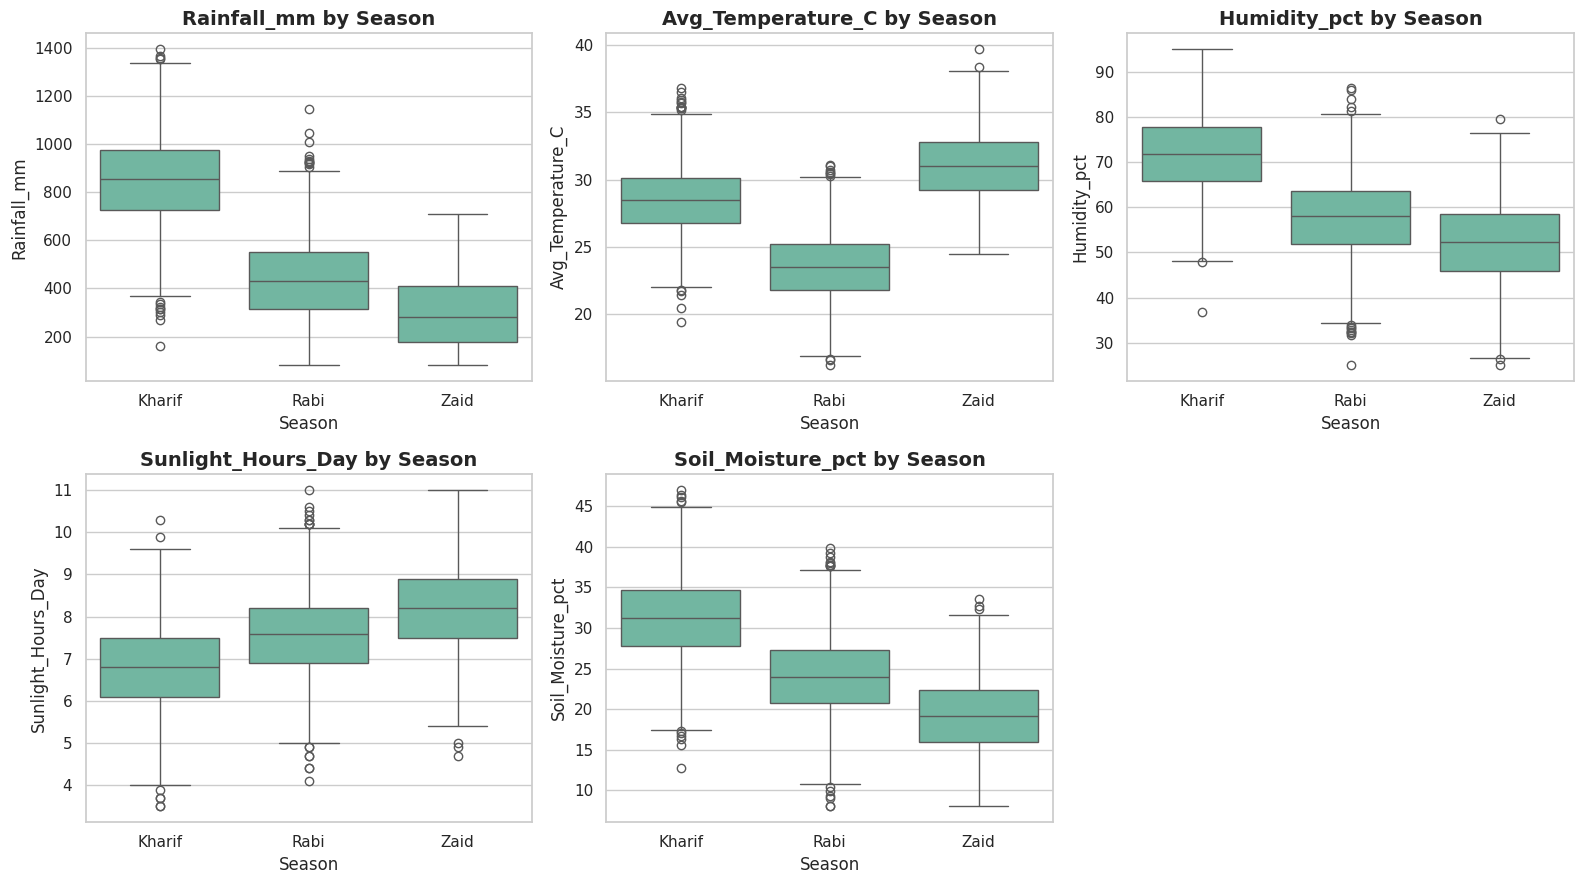

In [13]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER, ax=axes[i])
    axes[i].set_title(f'{col} by Season')
axes[-1].axis('off')
plt.tight_layout()
plt.show()


In [14]:
df.groupby('Season')[env_cols].agg(['mean', 'median', 'std']).round(2)


Rainfall_mm                 Avg_Temperature_C              Humidity_pct              Sunlight_Hours_Day               \
              mean  median     std              mean median   std         mean median   std               mean median   std   
Season                                                                                                                        
Kharif      852.11  854.75  181.57             28.45   28.5  2.51        71.81  71.90  8.86               6.79    6.8  0.98   
Rabi        435.94  430.30  174.69             23.49   23.5  2.46        57.89  58.10  9.00               7.59    7.6  1.00   
Zaid        299.12  283.30  152.56             31.04   31.0  2.55        52.01  52.35  9.05               8.18    8.2  1.05   

       Soil_Moisture_pct               
                    mean median   std  
Season                                 
Kharif             31.20   31.2  5.02  
Rabi               24.05   24.0  4.94  
Zaid               19.17   19.1  4.86

## 10. Seasonal Differences in Resource Usage

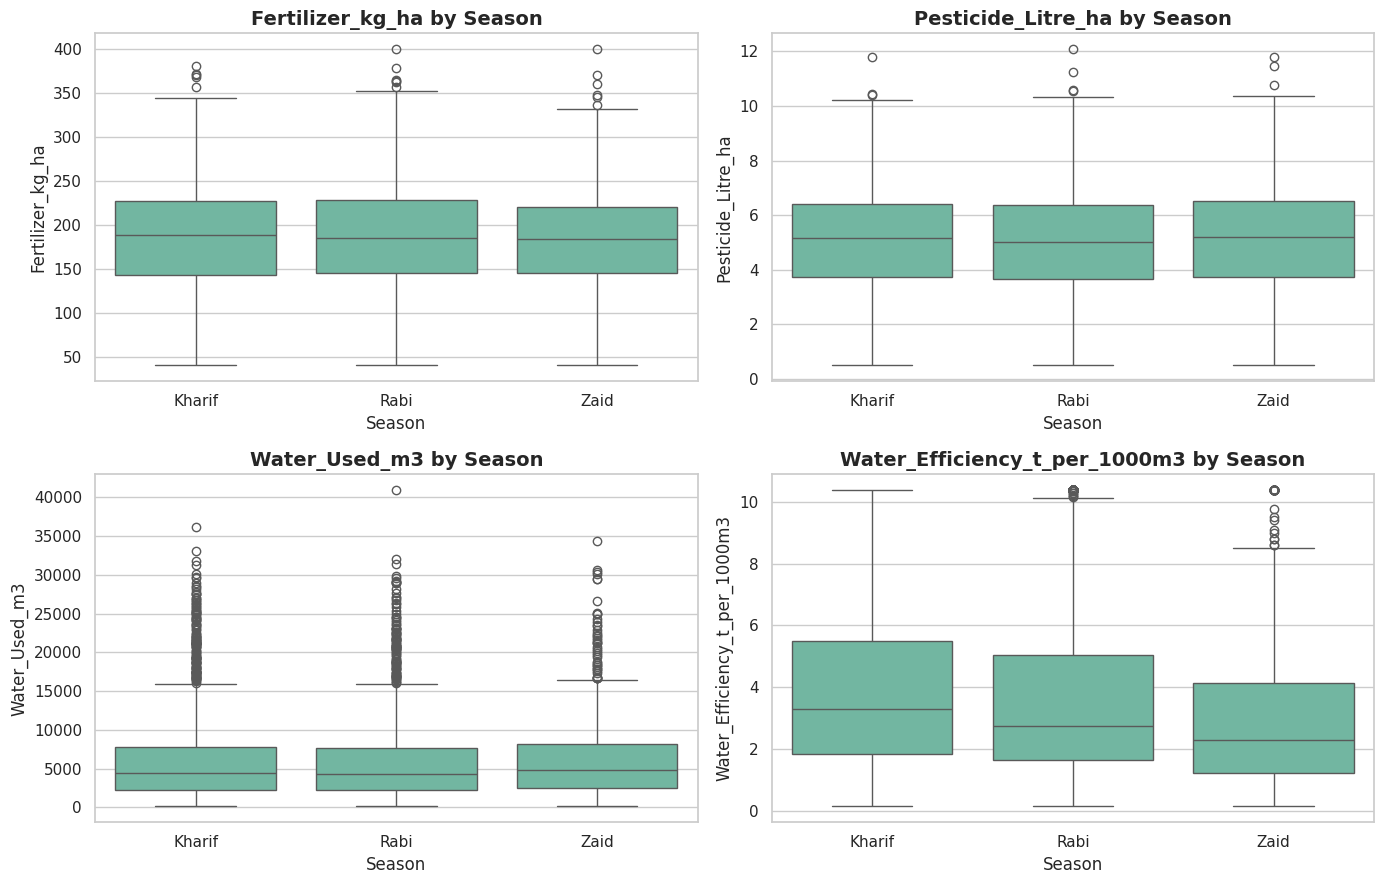

In [15]:
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
for i, col in enumerate(resource_cols):
    sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER, ax=axes[i])
    axes[i].set_title(f'{col} by Season')
plt.tight_layout()
plt.show()


In [16]:
irrigation_by_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index') * 100
irrigation_by_season = irrigation_by_season.round(1)
irrigation_by_season


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


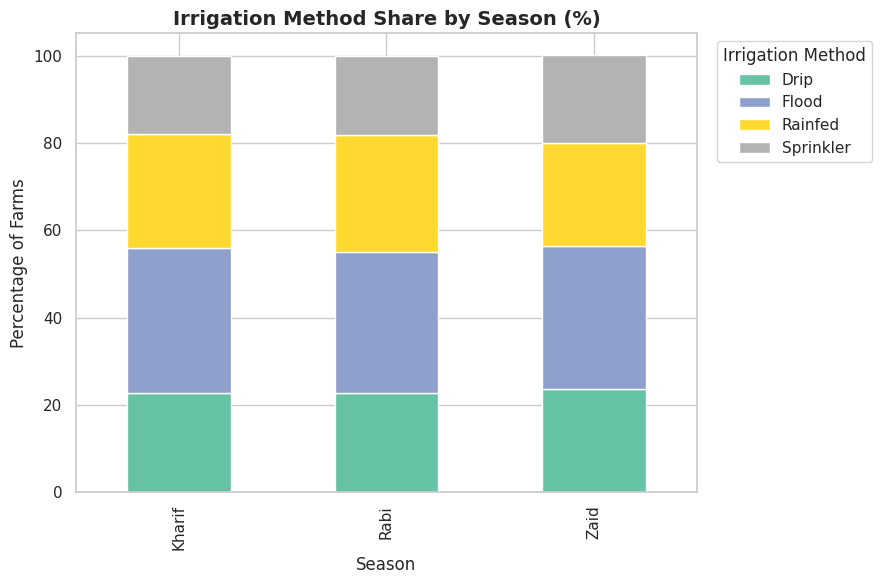

In [17]:
irrigation_by_season.plot(kind='bar', stacked=True, figsize=(9, 6), colormap='Set2')
plt.title('Irrigation Method Share by Season (%)')
plt.ylabel('Percentage of Farms')
plt.xlabel('Season')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 11. Seasonal Differences in Yield & Production

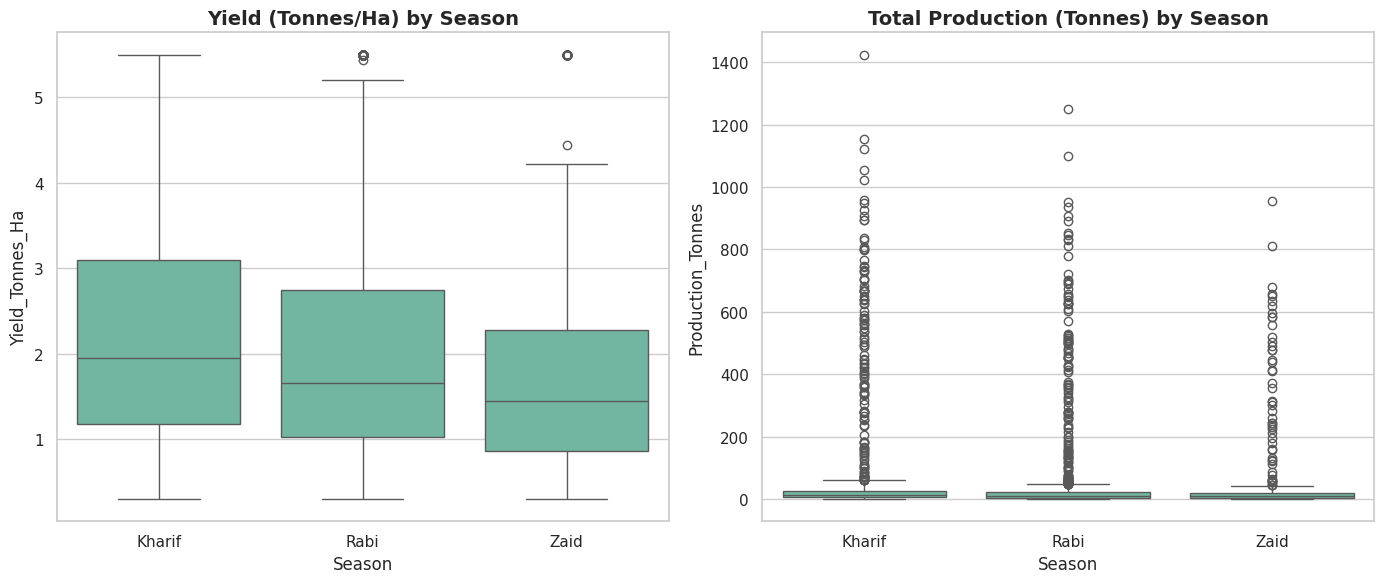

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER, ax=axes[0])
axes[0].set_title('Yield (Tonnes/Ha) by Season')

sns.boxplot(data=df, x='Season', y='Production_Tonnes', order=SEASON_ORDER, ax=axes[1])
axes[1].set_title('Total Production (Tonnes) by Season')
plt.tight_layout()
plt.show()


In [19]:
df.groupby('Season')[['Yield_Tonnes_Ha', 'Production_Tonnes', 'Disease_Pest_Risk_pct']].agg(['mean', 'median']).round(2)


Yield_Tonnes_Ha        Production_Tonnes        Disease_Pest_Risk_pct       
                  mean median              mean median                  mean median
Season                                                                             
Kharif            2.25   1.95             46.31  13.24                 54.47   54.5
Rabi              2.03   1.66             41.49  11.08                 40.48   40.6
Zaid              1.81   1.45             38.89   9.97                 38.22   37.9

### 11.1 Statistical Test: Is the yield difference across seasons significant?
A one-way ANOVA tests whether mean `Yield_Tonnes_Ha` differs significantly across the three
seasons.

In [20]:
groups = [df.loc[df['Season'] == s, 'Yield_Tonnes_Ha'] for s in SEASON_ORDER]
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("=> Statistically significant difference in yield across seasons (p < 0.05).")
else:
    print("=> No statistically significant difference in yield across seasons (p >= 0.05).")


ANOVA F-statistic: 25.422
P-value: 0.00000
=> Statistically significant difference in yield across seasons (p < 0.05).


## 12. Seasonal Differences in Economic Performance

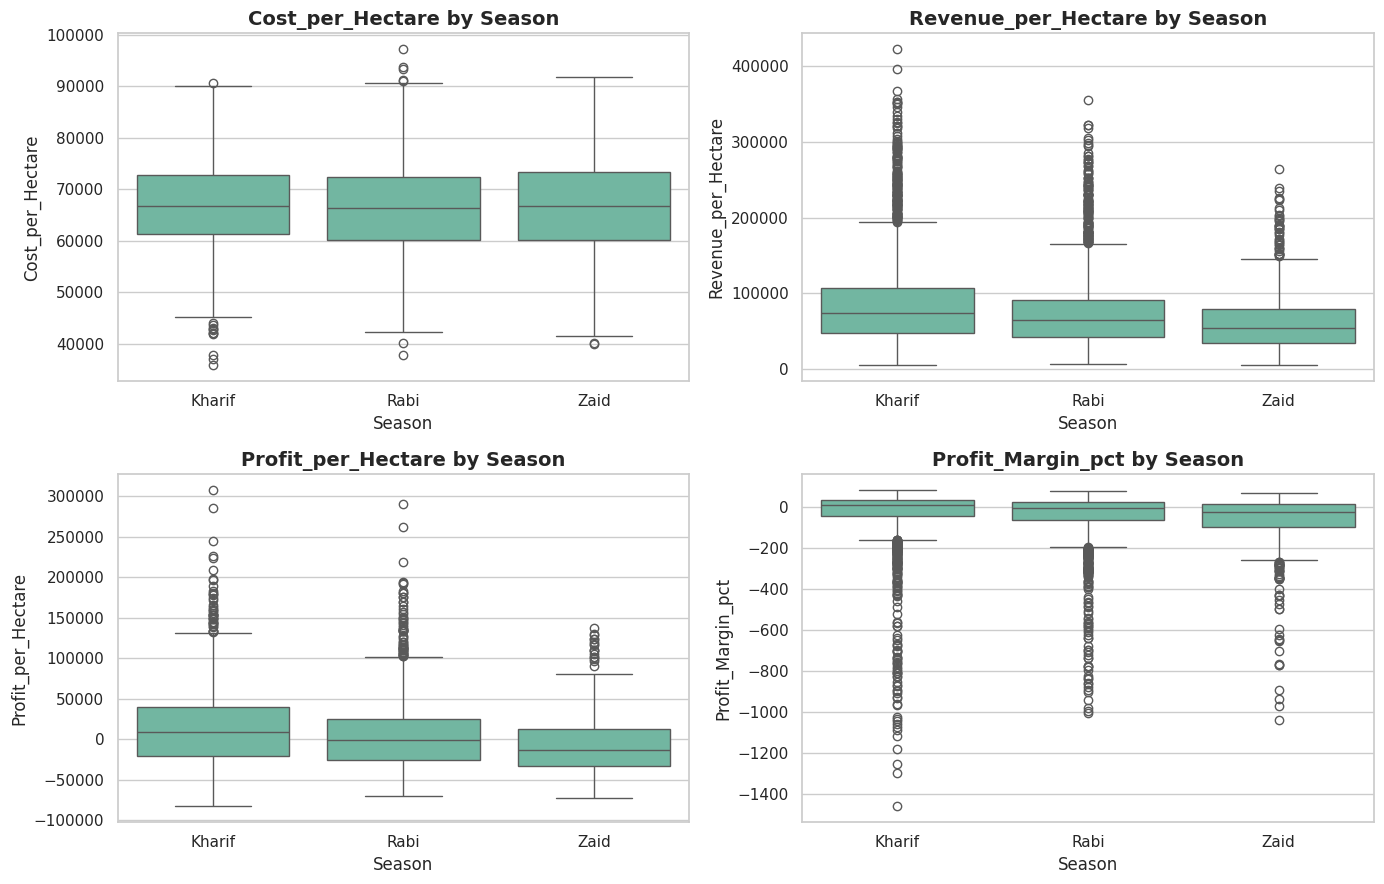

In [21]:
econ_cols = ['Cost_per_Hectare', 'Revenue_per_Hectare', 'Profit_per_Hectare', 'Profit_Margin_pct']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
for i, col in enumerate(econ_cols):
    sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER, ax=axes[i])
    axes[i].set_title(f'{col} by Season')
plt.tight_layout()
plt.show()


In [22]:
df.groupby('Season')[econ_cols].mean().round(2)


,Cost_per_Hectare,Revenue_per_Hectare,Profit_per_Hectare,Profit_Margin_pct
Season,,,,
Kharif,66900.98,88782.79,13846.78,-40.96
Rabi,66295.24,76656.92,5991.92,-45.36
Zaid,66937.94,64301.42,-4814.23,-69.21


### 12.1 Statistical Test: Profit per Hectare across seasons

In [23]:
groups = [df.loc[df['Season'] == s, 'Profit_per_Hectare'] for s in SEASON_ORDER]
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("=> Statistically significant difference in profit per hectare across seasons (p < 0.05).")
else:
    print("=> No statistically significant difference in profit per hectare across seasons (p >= 0.05).")


ANOVA F-statistic: 40.379
P-value: 0.00000
=> Statistically significant difference in profit per hectare across seasons (p < 0.05).


## 13. Are Seasonal Patterns Consistent Across States and Crops?

In [24]:
pivot_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='State', columns='Season', aggfunc='mean').round(2)
pivot_yield


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,2.34,1.67,1.86
Gujarat,2.14,2.06,1.85
Karnataka,2.35,2.06,1.87
Madhya Pradesh,2.27,1.85,1.79
Maharashtra,2.27,2.08,1.63
Punjab,2.17,2.37,1.81
Tamil Nadu,2.12,2.09,1.72
Telangana,2.35,2.10,1.90


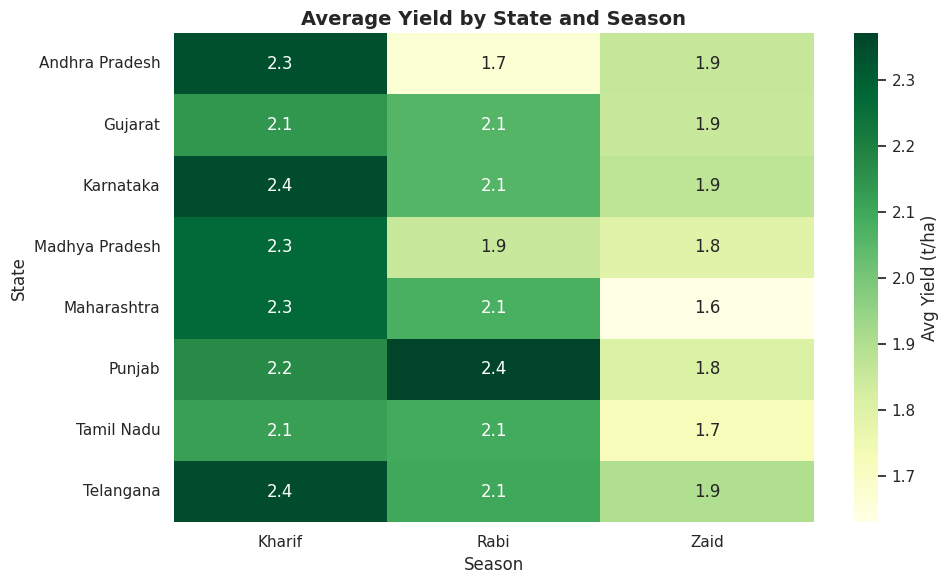

In [25]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_yield, annot=True, fmt='.1f', cmap='YlGn', cbar_kws={'label': 'Avg Yield (t/ha)'})
plt.title('Average Yield by State and Season')
plt.tight_layout()
plt.show()


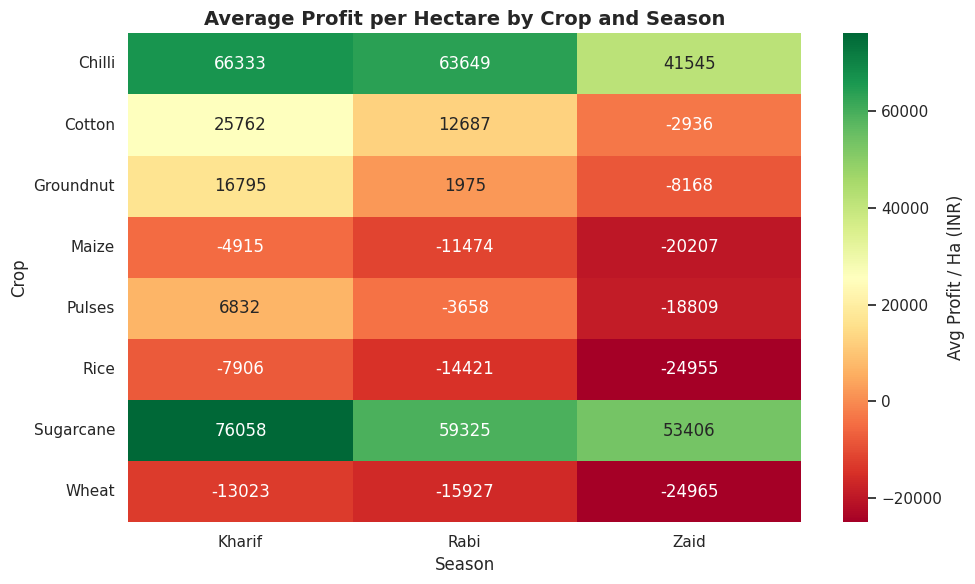

In [26]:
pivot_profit = df.pivot_table(values='Profit_per_Hectare', index='Crop', columns='Season', aggfunc='mean').round(0)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='RdYlGn', cbar_kws={'label': 'Avg Profit / Ha (INR)'})
plt.title('Average Profit per Hectare by Crop and Season')
plt.tight_layout()
plt.show()


## 14. Correlation Analysis

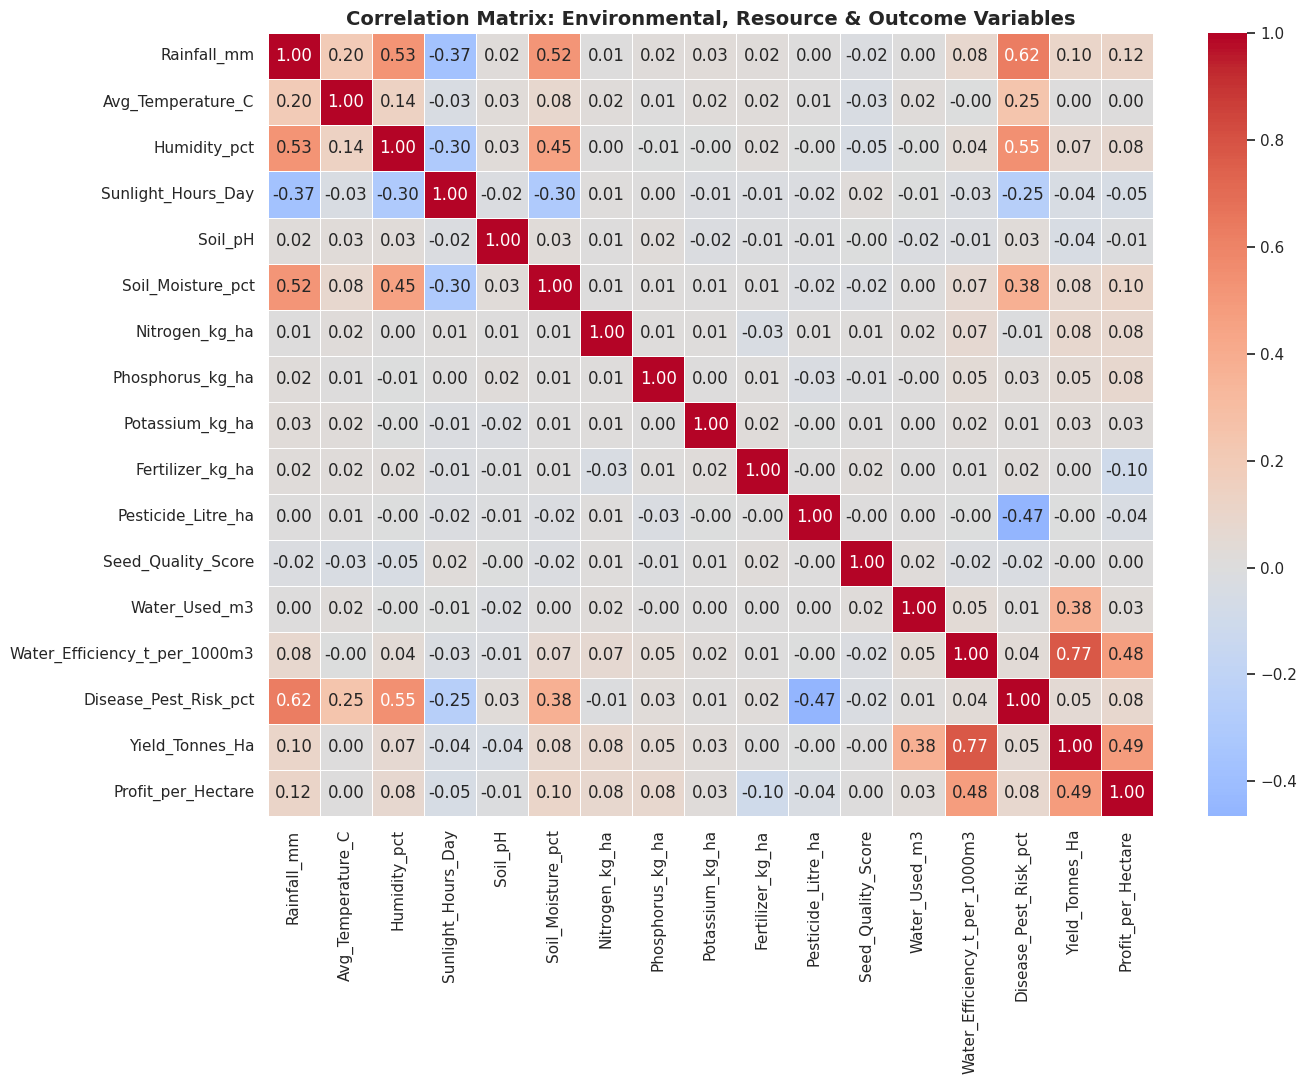

In [27]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
             'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha',
             'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
             'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct',
             'Yield_Tonnes_Ha', 'Profit_per_Hectare']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix: Environmental, Resource & Outcome Variables')
plt.tight_layout()
plt.show()


In [28]:
# Top correlations with Yield and Profit specifically
yield_corr = corr_matrix['Yield_Tonnes_Ha'].drop(['Yield_Tonnes_Ha', 'Profit_per_Hectare']).sort_values(ascending=False)
profit_corr = corr_matrix['Profit_per_Hectare'].drop(['Yield_Tonnes_Ha', 'Profit_per_Hectare']).sort_values(ascending=False)

print("Correlation with Yield_Tonnes_Ha (sorted):")
print(yield_corr)
print("\nCorrelation with Profit_per_Hectare (sorted):")
print(profit_corr)


Correlation with Yield_Tonnes_Ha (sorted):
Water_Efficiency_t_per_1000m3    0.772986
Water_Used_m3                    0.377703
Rainfall_mm                      0.102223
Soil_Moisture_pct                0.084191
Nitrogen_kg_ha                   0.080047
Humidity_pct                     0.065544
Phosphorus_kg_ha                 0.054219
Disease_Pest_Risk_pct            0.053701
Potassium_kg_ha                  0.030363
Fertilizer_kg_ha                 0.003586
Avg_Temperature_C                0.003138
Seed_Quality_Score              -0.000498
Pesticide_Litre_ha              -0.004387
Soil_pH                         -0.037989
Sunlight_Hours_Day              -0.042385
Name: Yield_Tonnes_Ha, dtype: float64

Correlation with Profit_per_Hectare (sorted):
Water_Efficiency_t_per_1000m3    0.479700
Rainfall_mm                      0.116613
Soil_Moisture_pct                0.103614
Disease_Pest_Risk_pct            0.081224
Phosphorus_kg_ha                 0.081075
Nitrogen_kg_ha                  

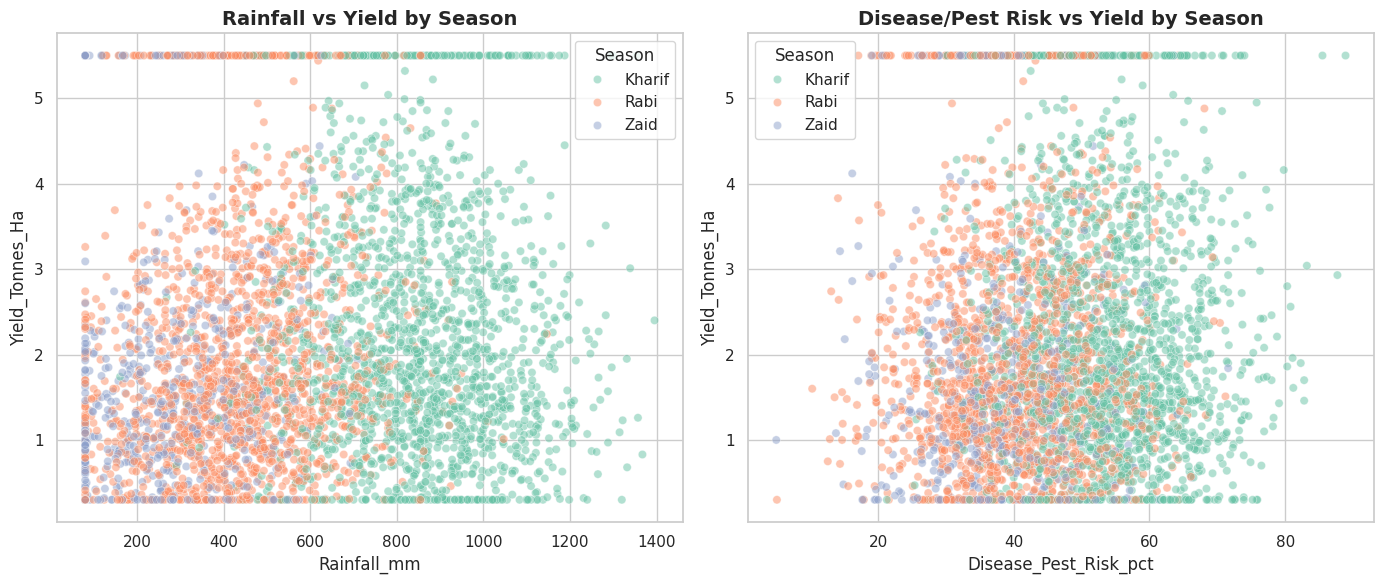

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', hue_order=SEASON_ORDER, alpha=0.5, ax=axes[0])
axes[0].set_title('Rainfall vs Yield by Season')

sns.scatterplot(data=df, x='Disease_Pest_Risk_pct', y='Yield_Tonnes_Ha', hue='Season', hue_order=SEASON_ORDER, alpha=0.5, ax=axes[1])
axes[1].set_title('Disease/Pest Risk vs Yield by Season')
plt.tight_layout()
plt.show()


## 15. Disease & Pest Risk Across Seasons

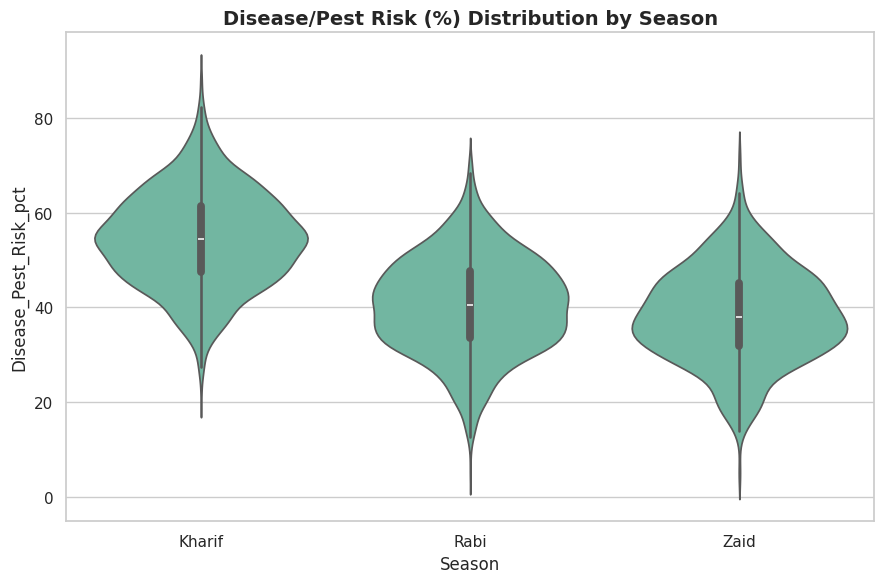

In [30]:
plt.figure(figsize=(9, 6))
sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER)
plt.title('Disease/Pest Risk (%) Distribution by Season')
plt.tight_layout()
plt.show()


## 16. Key Insights & Findings

*(Based on the actual output of this notebook run. If you re-run it after modifying the
cleaning/outlier steps, re-check these numbers.)*

1. **Yield is highest in Kharif and lowest in Zaid.** Average yield is **2.25 t/ha in
   Kharif**, **2.03 t/ha in Rabi**, and **1.81 t/ha in Zaid**. A one-way ANOVA confirms this
   difference is statistically significant (F = 25.42, p < 0.001).
2. **Environmental conditions follow a clear seasonal signature.** Kharif is the wettest and
   most humid season (avg. rainfall ≈ 852 mm, humidity ≈ 72%), Rabi is the coolest
   (avg. temperature ≈ 23.5°C) with moderate rainfall (≈ 436 mm), and Zaid is the hottest and
   driest (avg. temperature ≈ 31°C, rainfall ≈ 299 mm).
3. **Water efficiency — not rainfall or fertilizer — is the strongest driver of yield and
   profit.** `Water_Efficiency_t_per_1000m3` correlates strongly with yield (r ≈ 0.77) and
   moderately with profit per hectare (r ≈ 0.48). Rainfall's correlation with yield is
   comparatively weak (r ≈ 0.10), and `Fertilizer_kg_ha` shows almost no correlation with
   yield (r ≈ 0.00) and a small negative correlation with profit (r ≈ -0.10) — suggesting
   fertilizer usage in this dataset is not yield-limiting and may be over-applied in places.
4. **Profitability drops sharply from Kharif to Zaid, more sharply than yield does.**
   Average profit per hectare is **≈ ₹13,847 in Kharif**, **≈ ₹5,992 in Rabi**, and
   **≈ -₹4,814 (a loss) in Zaid** — even though the cost per hectare is nearly identical
   across all three seasons (₹66,300–₹66,940). The gap is driven by falling
   revenue per hectare (₹88,783 → ₹76,657 → ₹64,301), not rising costs. This difference is
   also statistically significant (ANOVA F = 40.38, p < 0.001).
5. **Disease/pest risk is highest in Kharif** (mean ≈ 54.5%) and lowest in Zaid
   (mean ≈ 38.2%) — the humid monsoon season creates more favorable conditions for
   disease/pest pressure, yet Kharif still has the best yield and profit outcomes overall,
   showing that rainfall/water availability outweighs the disease-risk penalty in this
   dataset.
6. **Irrigation method mix is fairly stable across seasons**, with a modest shift: Rainfed
   irrigation's share drops slightly in Zaid (≈ 23.6%) compared to Kharif/Rabi (≈ 26–27%),
   consistent with farmers relying less on natural rainfall in the driest season.
7. **State and crop patterns are broadly consistent** with the overall Kharif > Rabi > Zaid
   ordering (see the heatmaps in Section 13), though a few state–crop combinations deviate —
   worth a closer look if you are targeting a specific region or crop.

## 17. Conclusions & Recommendations

**Conclusion:** Kharif is the strongest-performing season in this dataset on both yield and
profitability, driven primarily by better water availability (reflected in higher water
efficiency) rather than by fertilizer input or lower disease/pest risk — in fact Kharif has
the *highest* disease/pest risk of the three seasons. Zaid is the weakest season: lower yield,
sharply lower revenue per hectare, and a net loss on average, despite similar costs to the
other seasons.

- **Recommendation 1 — Prioritize water efficiency over fertilizer.** Since water efficiency
  is by far the strongest correlate of yield and profit, and fertilizer usage shows almost no
  positive relationship with either, resources may be better spent on irrigation
  efficiency (e.g. drip/sprinkler adoption, scheduling) than on additional fertilizer.
- **Recommendation 2 — Address the Zaid season's revenue shortfall specifically.** Since
  Zaid's costs are comparable to Kharif/Rabi but revenue is much lower, focus on
  market-price timing, crop selection, or yield-boosting measures for Zaid rather than
  cost-cutting.
- **Recommendation 3 — Manage disease/pest risk proactively in Kharif.** Kharif already
  performs best overall, but its higher disease/pest risk represents unrealized upside;
  preventive pest management ahead of the monsoon could push Kharif profitability even
  higher.
- **Recommendation 4 — Tailor planning by state/crop, not just by season.** The state- and
  crop-level heatmaps show the seasonal pattern is not perfectly uniform; regions or crops
  that deviate from the overall trend should get season-specific planning rather than a
  one-size-fits-all national rule.
